In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install praat-parselmouth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 27.9 MB/s eta 0:00:00


# Sentence Level

Loading 360 files | Condition: Sentence-Level
  Processing file 1/360...
  Processing file 21/360...
  Processing file 41/360...
  Processing file 61/360...
  Processing file 81/360...
  Processing file 101/360...
  Processing file 121/360...
  Processing file 141/360...
  Processing file 161/360...
  Processing file 181/360...
  Processing file 201/360...
  Processing file 221/360...
  Processing file 241/360...
  Processing file 261/360...
  Processing file 281/360...
  Processing file 301/360...
  Processing file 321/360...
  Processing file 341/360...

Dataset loaded: 360 samples, 41 features
Actors: ['01' '03' '05' '07' '09' '11']
Class distribution:
Calm         48
Happy        48
Sad          48
Angry        48
Fearful      48
Surprised    48
Disgust      48
Neutral      24

Running LOOCV (6 folds)...
  Actor 01 | Train:  300 samples | Test:  60 samples | Acc: 0.317 | Macro-F1: 0.291
  Actor 03 | Train:  300 samples | Test:  60 samples | Acc: 0.483 | Macro-F1: 0.415


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Actor 05 | Train:  300 samples | Test:  60 samples | Acc: 0.483 | Macro-F1: 0.418
  Actor 07 | Train:  300 samples | Test:  60 samples | Acc: 0.367 | Macro-F1: 0.327
  Actor 09 | Train:  300 samples | Test:  60 samples | Acc: 0.383 | Macro-F1: 0.375


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Actor 11 | Train:  300 samples | Test:  60 samples | Acc: 0.367 | Macro-F1: 0.336

RESULTS SUMMARY — Sentence-Level
  Mean Accuracy  : 0.4000  ±  0.0624
  Mean Macro-F1  : 0.3602  ±  0.0467
  Mean Precision : 0.4810  ±  0.0365
  Mean Recall    : 0.3828  ±  0.0590

Per-class report (aggregated across all folds):
              precision    recall  f1-score   support

     Neutral       0.09      0.12      0.10        24
        Calm       0.71      0.42      0.53        48
       Happy       0.39      0.31      0.35        48
         Sad       0.34      0.42      0.38        48
       Angry       0.57      0.62      0.59        48
     Fearful       0.43      0.44      0.43        48
     Disgust       0.35      0.48      0.40        48
   Surprised       0.35      0.25      0.29        48

    accuracy                           0.40       360
   macro avg       0.40      0.38      0.38       360
weighted avg       0.43      0.40      0.40       360



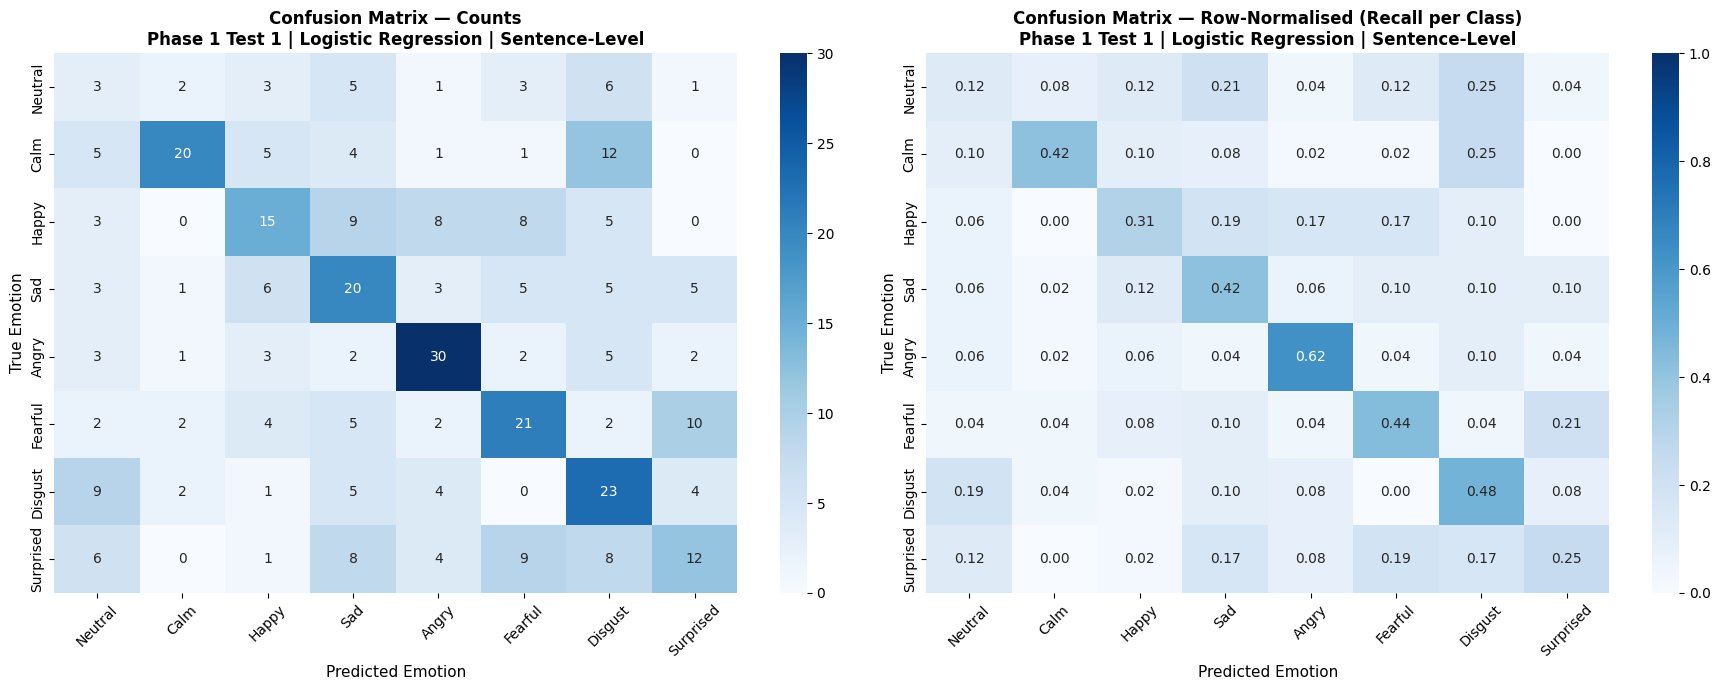

Confusion matrix saved.


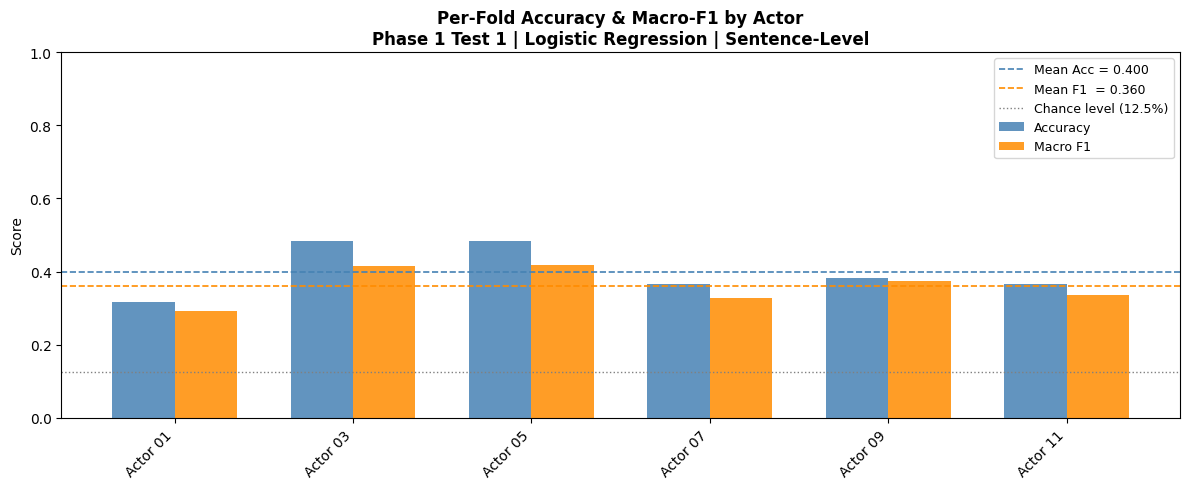

Per-fold plot saved.

Fold-level metrics saved to P1T1_fold_metrics_Sentence-Level.csv
Summary metrics saved to P1T1_summary_Sentence-Level.csv

Done. Change WINDOW_DURATION_SEC and re-run for the next condition.
Conditions to run: None (sentence-level), 2, 1


In [ ]:
# =============================================================================
# DAVIS - Phase 1, Test 1: Temporal Representation Experiment
# Goal: Determine the best temporal segmentation for emotion classification
# Conditions: sentence-level, 2s windows, 1s windows
# Model: Logistic Regression with LOOCV
# =============================================================================

import os
import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import parselmouth
import soundfile as sf
from parselmouth.praat import call
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)
from collections import defaultdict

# =============================================================================
# CONFIGURATION — change window settings here
# Set WINDOW_DURATION_SEC to None for sentence-level (no windowing)
# Set to a number (e.g. 2, 1) for fixed-length windows
# OVERLAP_SEC only applies when WINDOW_DURATION_SEC is not None
# =============================================================================

DATASET_PATH = "/content/drive/My Drive/Neuroscience/Research/ravdess_male"
SAMPLE_RATE   = 16000

# --- CHANGE THIS to switch between conditions ---
WINDOW_DURATION_SEC = None   # Options: None (sentence-level), 2, 1
# ------------------------------------------------

OVERLAP_SEC = 0              # set to 0 for non-overlapping windows (no leakage)

# Condition label used in plot/print titles
CONDITION_LABEL = (
    "Sentence-Level"
    if WINDOW_DURATION_SEC is None
    else f"{WINDOW_DURATION_SEC}s Windows (non-overlapping)"
)

emotion_map = {
    "01": "Neutral",
    "02": "Calm",
    "03": "Happy",
    "04": "Sad",
    "05": "Angry",
    "06": "Fearful",
    "07": "Disgust",
    "08": "Surprised",
}
EMOTION_LABELS = list(emotion_map.values())

# =============================================================================
# FEATURE EXTRACTION
# =============================================================================

def extract_parselmouth_features(y, sr):
    """Extract jitter, shimmer, HNR via Parselmouth (Praat interface)."""
    temp_filename = "temp_praat.wav"
    sf.write(temp_filename, y, sr)
    try:
        snd = parselmouth.Sound(temp_filename)
        point_process = call(snd, "To PointProcess (periodic, cc)", 75, 500)
        jitter   = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        shimmer  = call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        harmonicity = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr      = call(harmonicity, "Get mean", 0, 0)
    except Exception:
        jitter, shimmer, hnr = 0.0, 0.0, 0.0
    finally:
        if os.path.exists(temp_filename):
            os.remove(temp_filename)
    return [jitter, shimmer, hnr]


def extract_features(y_clip, sr):
    """
    Extract full 41-feature vector from an audio clip.
    Features: 13 MFCCs (mean+std=26), pitch stats (5),
              energy/RMS stats (5), ZCR (2), jitter/shimmer/HNR (3)
    """
    # MFCCs
    mfccs        = librosa.feature.mfcc(y=y_clip, sr=sr, n_mfcc=13)
    mfccs_mean   = np.mean(mfccs, axis=1)
    mfccs_std    = np.std(mfccs, axis=1)

    # Pitch
    pitches, magnitudes = librosa.piptrack(y=y_clip, sr=sr)
    pitches = pitches[magnitudes > np.median(magnitudes)]
    pitch_mean  = np.mean(pitches)  if len(pitches) > 0 else 0.0
    pitch_std   = np.std(pitches)   if len(pitches) > 0 else 0.0
    pitch_min   = np.min(pitches)   if len(pitches) > 0 else 0.0
    pitch_max   = np.max(pitches)   if len(pitches) > 0 else 0.0
    pitch_range = pitch_max - pitch_min

    # Energy (RMS)
    energy       = librosa.feature.rms(y=y_clip)[0]
    energy_mean  = np.mean(energy)
    energy_std   = np.std(energy)
    energy_min   = np.min(energy)
    energy_max   = np.max(energy)
    energy_range = energy_max - energy_min

    # Zero-crossing rate
    zcr      = librosa.feature.zero_crossing_rate(y_clip)[0]
    zcr_mean = np.mean(zcr)
    zcr_std  = np.std(zcr)

    # Voice quality (Parselmouth)
    jitter, shimmer, hnr = extract_parselmouth_features(y_clip, sr)

    return np.hstack([
        mfccs_mean, mfccs_std,
        [pitch_mean, pitch_std, pitch_min, pitch_max, pitch_range],
        [energy_mean, energy_std, energy_min, energy_max, energy_range],
        [zcr_mean, zcr_std],
        [jitter, shimmer, hnr]
    ])

# =============================================================================
# DATA LOADING
# Leakage prevention: actor-level split is done BEFORE windowing.
# Windows are generated per actor so no actor's windows appear in both
# train and test sets.
# =============================================================================

def load_dataset(dataset_path, window_sec, overlap_sec, sr):
    """
    Load RAVDESS files and segment into windows.
    Returns X, y (emotion labels), actors (actor IDs).
    Windowing is done per file — actor identity is preserved for LOOCV splitting.
    """
    X, y, actors = [], [], []

    files = [f for f in os.listdir(dataset_path) if f.endswith(".wav")]
    print(f"Loading {len(files)} files | Condition: {CONDITION_LABEL}")

    for i, file in enumerate(files):
        if i % 20 == 0:
            print(f"  Processing file {i+1}/{len(files)}...")

        parts      = file.split('-')
        emotion_id = parts[2]
        actor_id   = parts[-1].split('.')[0]
        emotion    = emotion_map.get(emotion_id, "Unknown")
        if emotion == "Unknown":
            continue

        file_path    = os.path.join(dataset_path, file)
        y_full, _    = librosa.load(file_path, sr=sr)

        if window_sec is None:
            # Sentence-level: use entire clip as one sample
            features = extract_features(y_full, sr)
            X.append(features)
            y.append(emotion)
            actors.append(actor_id)
        else:
            # Fixed-length non-overlapping windows
            samples_per_window = int(window_sec * sr)
            step               = samples_per_window  # no overlap → no leakage
            num_windows        = (len(y_full) - samples_per_window) // step + 1

            for w in range(num_windows):
                start = w * step
                end   = start + samples_per_window
                if end > len(y_full):
                    break
                clip     = y_full[start:end]
                features = extract_features(clip, sr)
                X.append(features)
                y.append(emotion)
                actors.append(actor_id)

    return np.array(X), np.array(y), np.array(actors)

# =============================================================================
# LOOCV EVALUATION
# =============================================================================

def run_loocv(X, y, actors):
    """
    Leave-One-Actor-Out Cross-Validation with Logistic Regression.
    Returns per-fold metrics and aggregated predictions.
    """
    unique_actors  = np.unique(actors)
    fold_metrics   = []
    all_y_true     = []
    all_y_pred     = []

    print(f"\nRunning LOOCV ({len(unique_actors)} folds)...")

    for test_actor in unique_actors:
        train_idx = np.where(actors != test_actor)[0]
        test_idx  = np.where(actors == test_actor)[0]

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler        = StandardScaler()
        X_train_sc    = scaler.fit_transform(X_train)
        X_test_sc     = scaler.transform(X_test)

        model = LogisticRegression(max_iter=1000, C=1.0,
                                   solver='lbfgs', multi_class='multinomial',
                                   random_state=42)
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)

        fold_acc  = accuracy_score(y_test, y_pred)
        fold_f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)
        fold_prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        fold_rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)

        fold_metrics.append({
            'actor':     test_actor,
            'n_train':   len(y_train),
            'n_test':    len(y_test),
            'accuracy':  fold_acc,
            'macro_f1':  fold_f1,
            'precision': fold_prec,
            'recall':    fold_rec
        })

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

        print(f"  Actor {test_actor} | "
              f"Train: {len(y_train):4d} samples | "
              f"Test: {len(y_test):3d} samples | "
              f"Acc: {fold_acc:.3f} | Macro-F1: {fold_f1:.3f}")

    return fold_metrics, np.array(all_y_true), np.array(all_y_pred)

# =============================================================================
# RESULTS REPORTING
# =============================================================================

def print_summary(fold_metrics, all_y_true, all_y_pred, condition_label):
    accs  = [m['accuracy']  for m in fold_metrics]
    f1s   = [m['macro_f1']  for m in fold_metrics]
    precs = [m['precision'] for m in fold_metrics]
    recs  = [m['recall']    for m in fold_metrics]

    print("\n" + "="*65)
    print(f"RESULTS SUMMARY — {condition_label}")
    print("="*65)
    print(f"  Mean Accuracy  : {np.mean(accs):.4f}  ±  {np.std(accs):.4f}")
    print(f"  Mean Macro-F1  : {np.mean(f1s):.4f}  ±  {np.std(f1s):.4f}")
    print(f"  Mean Precision : {np.mean(precs):.4f}  ±  {np.std(precs):.4f}")
    print(f"  Mean Recall    : {np.mean(recs):.4f}  ±  {np.std(recs):.4f}")
    print()
    print("Per-class report (aggregated across all folds):")
    print(classification_report(all_y_true, all_y_pred,
                                 labels=EMOTION_LABELS,
                                 target_names=EMOTION_LABELS,
                                 zero_division=0))

    return {
        'condition':       condition_label,
        'mean_accuracy':   np.mean(accs),
        'std_accuracy':    np.std(accs),
        'mean_macro_f1':   np.mean(f1s),
        'std_macro_f1':    np.std(f1s),
        'mean_precision':  np.mean(precs),
        'std_precision':   np.std(precs),
        'mean_recall':     np.mean(recs),
        'std_recall':      np.std(recs),
    }


def plot_confusion_matrix(all_y_true, all_y_pred, condition_label):
    cm = confusion_matrix(all_y_true, all_y_pred, labels=EMOTION_LABELS)

    # Raw counts
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
                ax=axes[0])
    axes[0].set_title(
        f"Confusion Matrix — Counts\n"
        f"Phase 1 Test 1 | Logistic Regression | {condition_label}",
        fontsize=12, fontweight='bold'
    )
    axes[0].set_xlabel("Predicted Emotion", fontsize=11)
    axes[0].set_ylabel("True Emotion", fontsize=11)
    axes[0].tick_params(axis='x', rotation=45)

    # Row-normalised (recall per class)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
                vmin=0, vmax=1, ax=axes[1])
    axes[1].set_title(
        f"Confusion Matrix — Row-Normalised (Recall per Class)\n"
        f"Phase 1 Test 1 | Logistic Regression | {condition_label}",
        fontsize=12, fontweight='bold'
    )
    axes[1].set_xlabel("Predicted Emotion", fontsize=11)
    axes[1].set_ylabel("True Emotion", fontsize=11)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(
        f"P1T1_confusion_matrix_{condition_label.replace(' ', '_').replace('(','').replace(')','')}.png",
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f"Confusion matrix saved.")


def plot_per_fold_accuracy(fold_metrics, condition_label):
    actors = [m['actor']    for m in fold_metrics]
    accs   = [m['accuracy'] for m in fold_metrics]
    f1s    = [m['macro_f1'] for m in fold_metrics]

    x = np.arange(len(actors))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    bars1 = ax.bar(x - width/2, accs, width, label='Accuracy',   color='steelblue',  alpha=0.85)
    bars2 = ax.bar(x + width/2, f1s,  width, label='Macro F1',   color='darkorange', alpha=0.85)

    ax.axhline(np.mean(accs), color='steelblue',  linestyle='--', linewidth=1.2,
               label=f'Mean Acc = {np.mean(accs):.3f}')
    ax.axhline(np.mean(f1s),  color='darkorange', linestyle='--', linewidth=1.2,
               label=f'Mean F1  = {np.mean(f1s):.3f}')
    ax.axhline(0.125, color='grey', linestyle=':', linewidth=1,
               label='Chance level (12.5%)')

    ax.set_xticks(x)
    ax.set_xticklabels([f'Actor {a}' for a in actors], rotation=45, ha='right')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.0)
    ax.set_title(
        f"Per-Fold Accuracy & Macro-F1 by Actor\n"
        f"Phase 1 Test 1 | Logistic Regression | {condition_label}",
        fontsize=12, fontweight='bold'
    )
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.savefig(
        f"P1T1_per_fold_{condition_label.replace(' ', '_').replace('(','').replace(')','')}.png",
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print("Per-fold plot saved.")

# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    # 1. Load data with current window condition
    X, y, actors = load_dataset(
        dataset_path=DATASET_PATH,
        window_sec=WINDOW_DURATION_SEC,
        overlap_sec=OVERLAP_SEC,
        sr=SAMPLE_RATE
    )
    print(f"\nDataset loaded: {X.shape[0]} samples, {X.shape[1]} features")
    print(f"Actors: {np.unique(actors)}")
    print(f"Class distribution:\n{pd.Series(y).value_counts().to_string()}")

    # 2. Run LOOCV
    fold_metrics, all_y_true, all_y_pred = run_loocv(X, y, actors)

    # 3. Print summary
    summary = print_summary(fold_metrics, all_y_true, all_y_pred, CONDITION_LABEL)

    # 4. Plots
    plot_confusion_matrix(all_y_true, all_y_pred, CONDITION_LABEL)
    plot_per_fold_accuracy(fold_metrics, CONDITION_LABEL)

    # 5. Save per-fold metrics to CSV for easy comparison across conditions
    df_folds = pd.DataFrame(fold_metrics)
    df_folds['condition'] = CONDITION_LABEL
    csv_name = f"P1T1_fold_metrics_{CONDITION_LABEL.replace(' ', '_').replace('(','').replace(')','')}.csv"
    df_folds.to_csv(csv_name, index=False)
    print(f"\nFold-level metrics saved to {csv_name}")

    # 6. Save summary row to CSV (append-friendly — run once per condition then combine)
    df_summary = pd.DataFrame([summary])
    summary_csv = f"P1T1_summary_{CONDITION_LABEL.replace(' ', '_').replace('(','').replace(')','')}.csv"
    df_summary.to_csv(summary_csv, index=False)
    print(f"Summary metrics saved to {summary_csv}")

    print("\nDone. Change WINDOW_DURATION_SEC and re-run for the next condition.")
    print("Conditions to run: None (sentence-level), 2, 1")

# 2 sec window

Loading 360 files | Condition: 2s Windows (non-overlapping)
  Processing file 1/360...
  Processing file 21/360...
  Processing file 41/360...
  Processing file 61/360...
  Processing file 81/360...
  Processing file 101/360...
  Processing file 121/360...
  Processing file 141/360...
  Processing file 161/360...
  Processing file 181/360...
  Processing file 201/360...
  Processing file 221/360...
  Processing file 241/360...
  Processing file 261/360...
  Processing file 281/360...
  Processing file 301/360...
  Processing file 321/360...
  Processing file 341/360...

Dataset loaded: 426 samples, 41 features
Actors: ['01' '03' '05' '07' '09' '11']
Class distribution:
Angry        66
Calm         65
Disgust      64
Happy        58
Surprised    50
Fearful      50
Sad          48
Neutral      25

Running LOOCV (6 folds)...
  Actor 01 | Train:  353 samples | Test:  73 samples | Acc: 0.233 | Macro-F1: 0.181
  Actor 03 | Train:  351 samples | Test:  75 samples | Acc: 0.467 | Macro-F1: 0.38

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

  Actor 11 | Train:  365 samples | Test:  61 samples | Acc: 0.410 | Macro-F1: 0.323

RESULTS SUMMARY — 2s Windows (non-overlapping)
  Mean Accuracy  : 0.4088  ±  0.0881
  Mean Macro-F1  : 0.3404  ±  0.0799
  Mean Precision : 0.4097  ±  0.0638
  Mean Recall    : 0.3708  ±  0.0752

Per-class report (aggregated across all folds):
              precision    recall  f1-score   support

     Neutral       0.06      0.08      0.07        25
        Calm       0.56      0.46      0.50        65
       Happy       0.40      0.33      0.36        58
         Sad       0.27      0.33      0.30        48
       Angry       0.60      0.76      0.67        66
     Fearful       0.43      0.40      0.41        50
     Disgust       0.41      0.41      0.41        64
   Surprised       0.35      0.24      0.29        50

    accuracy                           0.41       426
   macro avg       0.38      0.38      0.37       426
weighted avg       0.42      0.41      0.41       426



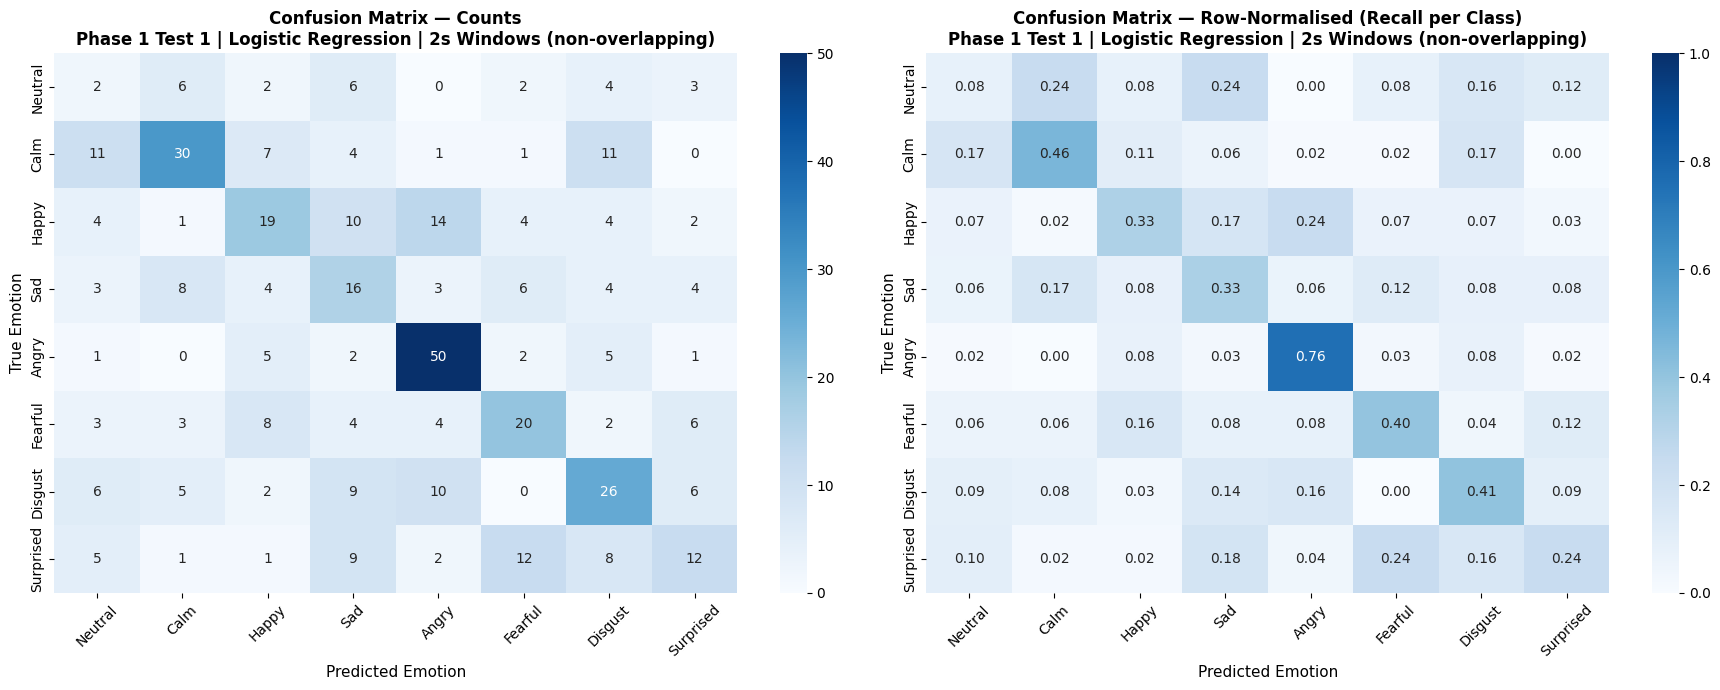

Confusion matrix saved.


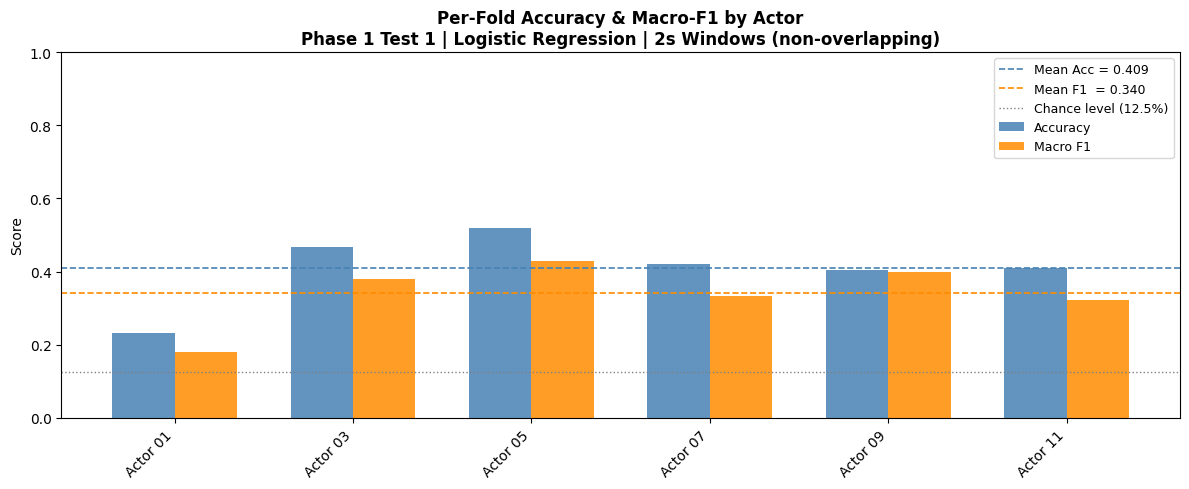

Per-fold plot saved.

Fold-level metrics saved to P1T1_fold_metrics_2s_Windows_non-overlapping.csv
Summary metrics saved to P1T1_summary_2s_Windows_non-overlapping.csv

Done. Change WINDOW_DURATION_SEC and re-run for the next condition.
Conditions to run: None (sentence-level), 2, 1


In [ ]:
# =============================================================================
# DAVIS - Phase 1, Test 1: Temporal Representation Experiment
# Goal: Determine the best temporal segmentation for emotion classification
# Conditions: sentence-level, 2s windows, 1s windows
# Model: Logistic Regression with LOOCV
# =============================================================================

import os
import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import parselmouth
import soundfile as sf
from parselmouth.praat import call
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)
from collections import defaultdict

# =============================================================================
# CONFIGURATION — change window settings here
# Set WINDOW_DURATION_SEC to None for sentence-level (no windowing)
# Set to a number (e.g. 2, 1) for fixed-length windows
# OVERLAP_SEC only applies when WINDOW_DURATION_SEC is not None
# =============================================================================

DATASET_PATH = "/content/drive/My Drive/Neuroscience/Research/ravdess_male"
SAMPLE_RATE   = 16000

# --- CHANGE THIS to switch between conditions ---
WINDOW_DURATION_SEC = 2   # Options: None (sentence-level), 2, 1
# ------------------------------------------------

OVERLAP_SEC = 0              # set to 0 for non-overlapping windows (no leakage)

# Condition label used in plot/print titles
CONDITION_LABEL = (
    "Sentence-Level"
    if WINDOW_DURATION_SEC is None
    else f"{WINDOW_DURATION_SEC}s Windows (non-overlapping)"
)

emotion_map = {
    "01": "Neutral",
    "02": "Calm",
    "03": "Happy",
    "04": "Sad",
    "05": "Angry",
    "06": "Fearful",
    "07": "Disgust",
    "08": "Surprised",
}
EMOTION_LABELS = list(emotion_map.values())

# =============================================================================
# FEATURE EXTRACTION
# =============================================================================

def extract_parselmouth_features(y, sr):
    """Extract jitter, shimmer, HNR via Parselmouth (Praat interface)."""
    temp_filename = "temp_praat.wav"
    sf.write(temp_filename, y, sr)
    try:
        snd = parselmouth.Sound(temp_filename)
        point_process = call(snd, "To PointProcess (periodic, cc)", 75, 500)
        jitter   = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        shimmer  = call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        harmonicity = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr      = call(harmonicity, "Get mean", 0, 0)
    except Exception:
        jitter, shimmer, hnr = 0.0, 0.0, 0.0
    finally:
        if os.path.exists(temp_filename):
            os.remove(temp_filename)
    return [jitter, shimmer, hnr]


def extract_features(y_clip, sr):
    """
    Extract full 41-feature vector from an audio clip.
    Features: 13 MFCCs (mean+std=26), pitch stats (5),
              energy/RMS stats (5), ZCR (2), jitter/shimmer/HNR (3)
    """
    # MFCCs
    mfccs        = librosa.feature.mfcc(y=y_clip, sr=sr, n_mfcc=13)
    mfccs_mean   = np.mean(mfccs, axis=1)
    mfccs_std    = np.std(mfccs, axis=1)

    # Pitch
    pitches, magnitudes = librosa.piptrack(y=y_clip, sr=sr)
    pitches = pitches[magnitudes > np.median(magnitudes)]
    pitch_mean  = np.mean(pitches)  if len(pitches) > 0 else 0.0
    pitch_std   = np.std(pitches)   if len(pitches) > 0 else 0.0
    pitch_min   = np.min(pitches)   if len(pitches) > 0 else 0.0
    pitch_max   = np.max(pitches)   if len(pitches) > 0 else 0.0
    pitch_range = pitch_max - pitch_min

    # Energy (RMS)
    energy       = librosa.feature.rms(y=y_clip)[0]
    energy_mean  = np.mean(energy)
    energy_std   = np.std(energy)
    energy_min   = np.min(energy)
    energy_max   = np.max(energy)
    energy_range = energy_max - energy_min

    # Zero-crossing rate
    zcr      = librosa.feature.zero_crossing_rate(y_clip)[0]
    zcr_mean = np.mean(zcr)
    zcr_std  = np.std(zcr)

    # Voice quality (Parselmouth)
    jitter, shimmer, hnr = extract_parselmouth_features(y_clip, sr)

    return np.hstack([
        mfccs_mean, mfccs_std,
        [pitch_mean, pitch_std, pitch_min, pitch_max, pitch_range],
        [energy_mean, energy_std, energy_min, energy_max, energy_range],
        [zcr_mean, zcr_std],
        [jitter, shimmer, hnr]
    ])

# =============================================================================
# DATA LOADING
# Leakage prevention: actor-level split is done BEFORE windowing.
# Windows are generated per actor so no actor's windows appear in both
# train and test sets.
# =============================================================================

def load_dataset(dataset_path, window_sec, overlap_sec, sr):
    """
    Load RAVDESS files and segment into windows.
    Returns X, y (emotion labels), actors (actor IDs).
    Windowing is done per file — actor identity is preserved for LOOCV splitting.
    """
    X, y, actors = [], [], []

    files = [f for f in os.listdir(dataset_path) if f.endswith(".wav")]
    print(f"Loading {len(files)} files | Condition: {CONDITION_LABEL}")

    for i, file in enumerate(files):
        if i % 20 == 0:
            print(f"  Processing file {i+1}/{len(files)}...")

        parts      = file.split('-')
        emotion_id = parts[2]
        actor_id   = parts[-1].split('.')[0]
        emotion    = emotion_map.get(emotion_id, "Unknown")
        if emotion == "Unknown":
            continue

        file_path    = os.path.join(dataset_path, file)
        y_full, _    = librosa.load(file_path, sr=sr)

        if window_sec is None:
            # Sentence-level: use entire clip as one sample
            features = extract_features(y_full, sr)
            X.append(features)
            y.append(emotion)
            actors.append(actor_id)
        else:
            # Fixed-length non-overlapping windows
            samples_per_window = int(window_sec * sr)
            step               = samples_per_window  # no overlap → no leakage
            num_windows        = (len(y_full) - samples_per_window) // step + 1

            for w in range(num_windows):
                start = w * step
                end   = start + samples_per_window
                if end > len(y_full):
                    break
                clip     = y_full[start:end]
                features = extract_features(clip, sr)
                X.append(features)
                y.append(emotion)
                actors.append(actor_id)

    return np.array(X), np.array(y), np.array(actors)

# =============================================================================
# LOOCV EVALUATION
# =============================================================================

def run_loocv(X, y, actors):
    """
    Leave-One-Actor-Out Cross-Validation with Logistic Regression.
    Returns per-fold metrics and aggregated predictions.
    """
    unique_actors  = np.unique(actors)
    fold_metrics   = []
    all_y_true     = []
    all_y_pred     = []

    print(f"\nRunning LOOCV ({len(unique_actors)} folds)...")

    for test_actor in unique_actors:
        train_idx = np.where(actors != test_actor)[0]
        test_idx  = np.where(actors == test_actor)[0]

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler        = StandardScaler()
        X_train_sc    = scaler.fit_transform(X_train)
        X_test_sc     = scaler.transform(X_test)

        model = LogisticRegression(max_iter=1000, C=1.0,
                                   solver='lbfgs', multi_class='multinomial',
                                   random_state=42)
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)

        fold_acc  = accuracy_score(y_test, y_pred)
        fold_f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)
        fold_prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        fold_rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)

        fold_metrics.append({
            'actor':     test_actor,
            'n_train':   len(y_train),
            'n_test':    len(y_test),
            'accuracy':  fold_acc,
            'macro_f1':  fold_f1,
            'precision': fold_prec,
            'recall':    fold_rec
        })

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

        print(f"  Actor {test_actor} | "
              f"Train: {len(y_train):4d} samples | "
              f"Test: {len(y_test):3d} samples | "
              f"Acc: {fold_acc:.3f} | Macro-F1: {fold_f1:.3f}")

    return fold_metrics, np.array(all_y_true), np.array(all_y_pred)

# =============================================================================
# RESULTS REPORTING
# =============================================================================

def print_summary(fold_metrics, all_y_true, all_y_pred, condition_label):
    accs  = [m['accuracy']  for m in fold_metrics]
    f1s   = [m['macro_f1']  for m in fold_metrics]
    precs = [m['precision'] for m in fold_metrics]
    recs  = [m['recall']    for m in fold_metrics]

    print("\n" + "="*65)
    print(f"RESULTS SUMMARY — {condition_label}")
    print("="*65)
    print(f"  Mean Accuracy  : {np.mean(accs):.4f}  ±  {np.std(accs):.4f}")
    print(f"  Mean Macro-F1  : {np.mean(f1s):.4f}  ±  {np.std(f1s):.4f}")
    print(f"  Mean Precision : {np.mean(precs):.4f}  ±  {np.std(precs):.4f}")
    print(f"  Mean Recall    : {np.mean(recs):.4f}  ±  {np.std(recs):.4f}")
    print()
    print("Per-class report (aggregated across all folds):")
    print(classification_report(all_y_true, all_y_pred,
                                 labels=EMOTION_LABELS,
                                 target_names=EMOTION_LABELS,
                                 zero_division=0))

    return {
        'condition':       condition_label,
        'mean_accuracy':   np.mean(accs),
        'std_accuracy':    np.std(accs),
        'mean_macro_f1':   np.mean(f1s),
        'std_macro_f1':    np.std(f1s),
        'mean_precision':  np.mean(precs),
        'std_precision':   np.std(precs),
        'mean_recall':     np.mean(recs),
        'std_recall':      np.std(recs),
    }


def plot_confusion_matrix(all_y_true, all_y_pred, condition_label):
    cm = confusion_matrix(all_y_true, all_y_pred, labels=EMOTION_LABELS)

    # Raw counts
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
                ax=axes[0])
    axes[0].set_title(
        f"Confusion Matrix — Counts\n"
        f"Phase 1 Test 1 | Logistic Regression | {condition_label}",
        fontsize=12, fontweight='bold'
    )
    axes[0].set_xlabel("Predicted Emotion", fontsize=11)
    axes[0].set_ylabel("True Emotion", fontsize=11)
    axes[0].tick_params(axis='x', rotation=45)

    # Row-normalised (recall per class)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
                vmin=0, vmax=1, ax=axes[1])
    axes[1].set_title(
        f"Confusion Matrix — Row-Normalised (Recall per Class)\n"
        f"Phase 1 Test 1 | Logistic Regression | {condition_label}",
        fontsize=12, fontweight='bold'
    )
    axes[1].set_xlabel("Predicted Emotion", fontsize=11)
    axes[1].set_ylabel("True Emotion", fontsize=11)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(
        f"P1T1_confusion_matrix_{condition_label.replace(' ', '_').replace('(','').replace(')','')}.png",
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f"Confusion matrix saved.")


def plot_per_fold_accuracy(fold_metrics, condition_label):
    actors = [m['actor']    for m in fold_metrics]
    accs   = [m['accuracy'] for m in fold_metrics]
    f1s    = [m['macro_f1'] for m in fold_metrics]

    x = np.arange(len(actors))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    bars1 = ax.bar(x - width/2, accs, width, label='Accuracy',   color='steelblue',  alpha=0.85)
    bars2 = ax.bar(x + width/2, f1s,  width, label='Macro F1',   color='darkorange', alpha=0.85)

    ax.axhline(np.mean(accs), color='steelblue',  linestyle='--', linewidth=1.2,
               label=f'Mean Acc = {np.mean(accs):.3f}')
    ax.axhline(np.mean(f1s),  color='darkorange', linestyle='--', linewidth=1.2,
               label=f'Mean F1  = {np.mean(f1s):.3f}')
    ax.axhline(0.125, color='grey', linestyle=':', linewidth=1,
               label='Chance level (12.5%)')

    ax.set_xticks(x)
    ax.set_xticklabels([f'Actor {a}' for a in actors], rotation=45, ha='right')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.0)
    ax.set_title(
        f"Per-Fold Accuracy & Macro-F1 by Actor\n"
        f"Phase 1 Test 1 | Logistic Regression | {condition_label}",
        fontsize=12, fontweight='bold'
    )
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.savefig(
        f"P1T1_per_fold_{condition_label.replace(' ', '_').replace('(','').replace(')','')}.png",
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print("Per-fold plot saved.")

# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    # 1. Load data with current window condition
    X, y, actors = load_dataset(
        dataset_path=DATASET_PATH,
        window_sec=WINDOW_DURATION_SEC,
        overlap_sec=OVERLAP_SEC,
        sr=SAMPLE_RATE
    )
    print(f"\nDataset loaded: {X.shape[0]} samples, {X.shape[1]} features")
    print(f"Actors: {np.unique(actors)}")
    print(f"Class distribution:\n{pd.Series(y).value_counts().to_string()}")

    # 2. Run LOOCV
    fold_metrics, all_y_true, all_y_pred = run_loocv(X, y, actors)

    # 3. Print summary
    summary = print_summary(fold_metrics, all_y_true, all_y_pred, CONDITION_LABEL)

    # 4. Plots
    plot_confusion_matrix(all_y_true, all_y_pred, CONDITION_LABEL)
    plot_per_fold_accuracy(fold_metrics, CONDITION_LABEL)

    # 5. Save per-fold metrics to CSV for easy comparison across conditions
    df_folds = pd.DataFrame(fold_metrics)
    df_folds['condition'] = CONDITION_LABEL
    csv_name = f"P1T1_fold_metrics_{CONDITION_LABEL.replace(' ', '_').replace('(','').replace(')','')}.csv"
    df_folds.to_csv(csv_name, index=False)
    print(f"\nFold-level metrics saved to {csv_name}")

    # 6. Save summary row to CSV (append-friendly — run once per condition then combine)
    df_summary = pd.DataFrame([summary])
    summary_csv = f"P1T1_summary_{CONDITION_LABEL.replace(' ', '_').replace('(','').replace(')','')}.csv"
    df_summary.to_csv(summary_csv, index=False)
    print(f"Summary metrics saved to {summary_csv}")

    print("\nDone. Change WINDOW_DURATION_SEC and re-run for the next condition.")
    print("Conditions to run: None (sentence-level), 2, 1")

# 1 sec window

Found 360 .wav files | Condition: 1s-Windows-Non-Overlapping
  Processing file 1/360...
  Processing file 21/360...
  Processing file 41/360...
  Processing file 61/360...
  Processing file 81/360...
  Processing file 101/360...
  Processing file 121/360...
  Processing file 141/360...
  Processing file 161/360...
  Processing file 181/360...
  Processing file 201/360...
  Processing file 221/360...
  Processing file 241/360...
  Processing file 261/360...
  Processing file 281/360...
  Processing file 301/360...
  Processing file 321/360...
  Processing file 341/360...

Dataset loaded: 1146 samples | Skipped 0 invalid clips

Feature matrix shape : (1146, 41)
Unique actors        : ['01' '03' '05' '07' '09' '11']
Class distribution:
Angry        162
Calm         161
Disgust      160
Fearful      147
Happy        154
Neutral       73
Sad          144
Surprised    145

NaN values in X : 0
Inf values in X : 0
Feature matrix is clean (no NaN/Inf).

Running LOOCV (6 folds) | 1s-Windows-Non-

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Actor 03 | Train:  951 | Test: 195 | Acc: 0.303 | Macro-F1: 0.249
  Actor 05 | Train:  947 | Test: 199 | Acc: 0.302 | Macro-F1: 0.246
  Actor 07 | Train:  950 | Test: 196 | Acc: 0.321 | Macro-F1: 0.252


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Actor 09 | Train:  964 | Test: 182 | Acc: 0.275 | Macro-F1: 0.262
  Actor 11 | Train:  966 | Test: 180 | Acc: 0.372 | Macro-F1: 0.333

RESULTS SUMMARY — 1s-Windows-Non-Overlapping
  Mean Accuracy  : 0.3102  ±  0.0312
  Mean Macro-F1  : 0.2686  ±  0.0297
  Mean Precision : 0.2988  ±  0.0367
  Mean Recall    : 0.2931  ±  0.0284

Per-class report (aggregated across all folds):
              precision    recall  f1-score   support

     Neutral       0.13      0.12      0.13        73
        Calm       0.40      0.41      0.40       161
       Happy       0.33      0.20      0.25       154
         Sad       0.24      0.31      0.27       144
       Angry       0.44      0.52      0.48       162
     Fearful       0.29      0.22      0.25       147
     Disgust       0.29      0.40      0.34       160
   Surprised       0.20      0.16      0.18       145

    accuracy                           0.31      1146
   macro avg       0.29      0.29      0.29      1146
weighted avg       0.31  

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


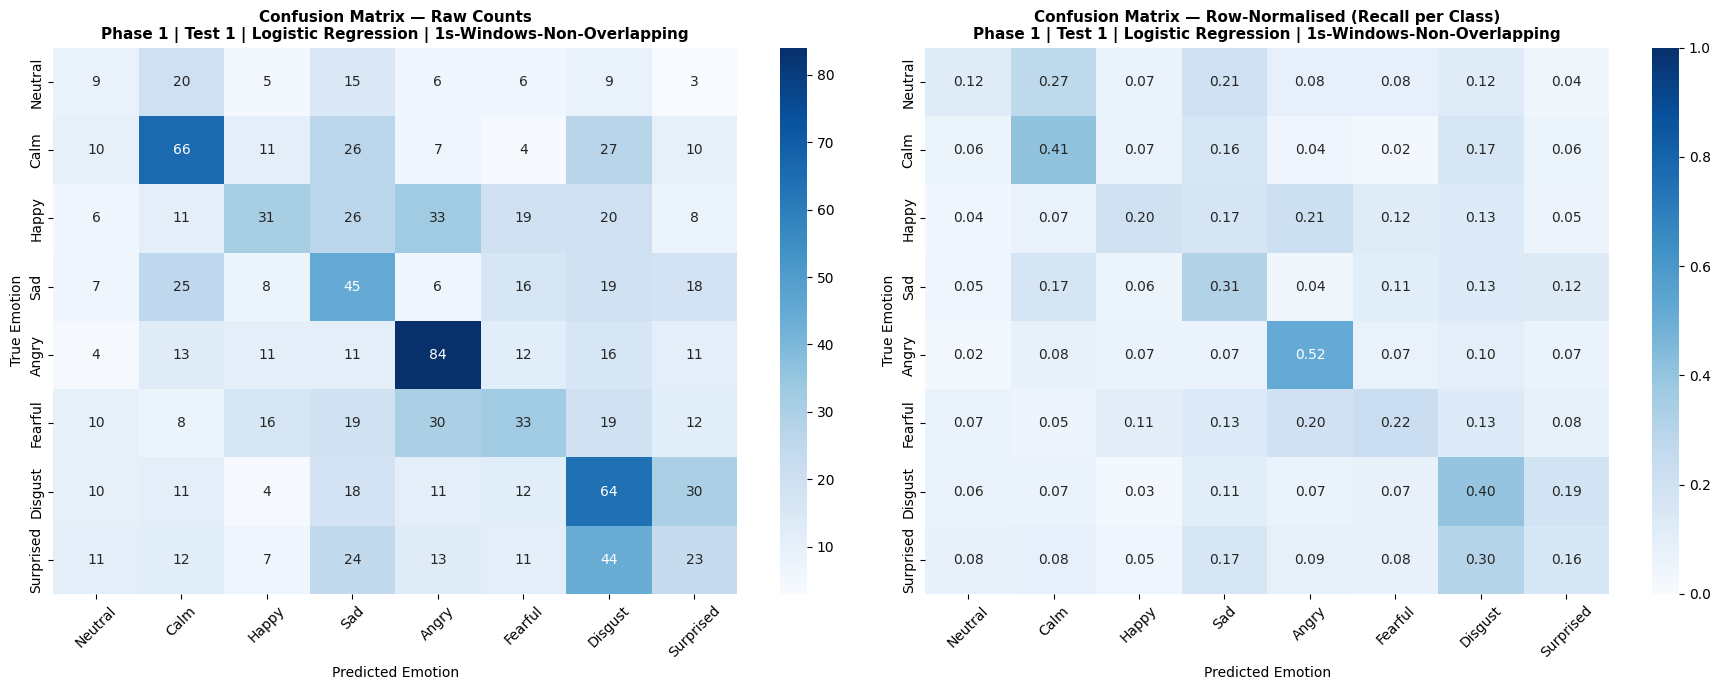

Saved: P1_T1_confusion_matrix_1s-Windows-Non-Overlapping.png


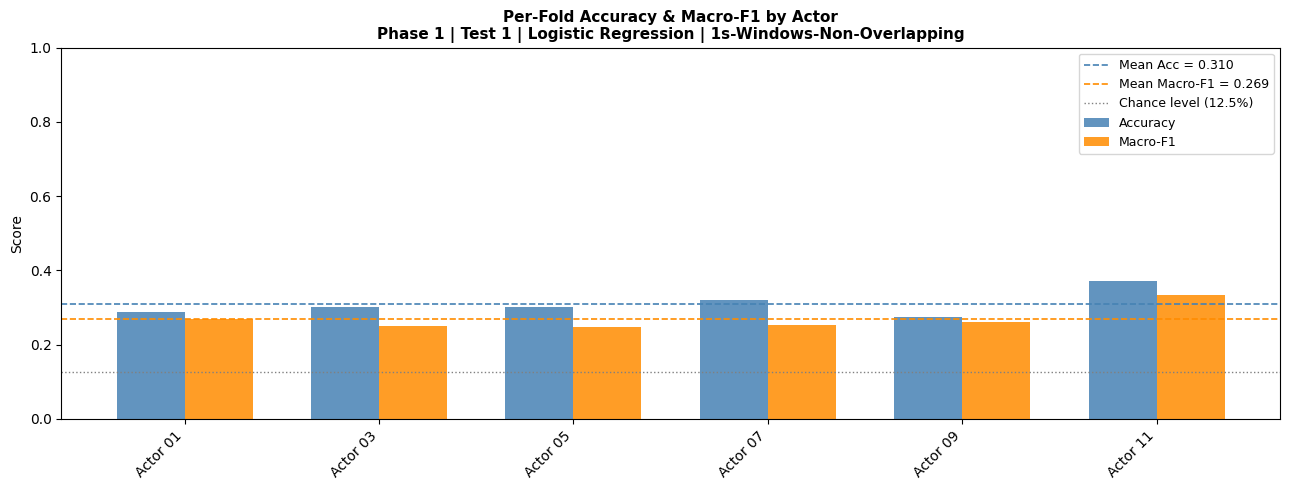

Saved: P1_T1_per_fold_1s-Windows-Non-Overlapping.png
Saved: P1_T1_fold_metrics_1s-Windows-Non-Overlapping.csv
Saved: P1_T1_summary_1s-Windows-Non-Overlapping.csv

Done. Change WINDOW_DURATION_SEC and re-run for the next condition.
Conditions to run: None (sentence-level), 2, 1


In [ ]:
# =============================================================================
# DAVIS - Phase 1, Test 1: Temporal Representation Experiment
# Goal: Determine the best temporal segmentation for emotion classification
# Conditions: sentence-level, 2s windows, 1s windows
# Model: Logistic Regression with LOOCV
# =============================================================================

import os
import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import parselmouth
import soundfile as sf
from parselmouth.praat import call
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)

# CONFIGURATION — change window settings here
# Set WINDOW_DURATION_SEC to None for sentence-level (no windowing)
# Set to a number (e.g. 2, 1) for fixed-length windows
# OVERLAP_SEC is kept at 0 (non-overlapping) to prevent data leakage

DATASET_PATH = "/content/drive/My Drive/Neuroscience/Research/ravdess_male"
SAMPLE_RATE  = 16000

#  to switch between conditions
WINDOW_DURATION_SEC = 1   # Options: None (sentence-level), 2, 1

# Condition label used in all plot titles and saved filenames
CONDITION_LABEL = (
    "Sentence-Level"
    if WINDOW_DURATION_SEC is None
    else f"{WINDOW_DURATION_SEC}s-Windows-Non-Overlapping"
)

emotion_map = {
    "01": "Neutral",
    "02": "Calm",
    "03": "Happy",
    "04": "Sad",
    "05": "Angry",
    "06": "Fearful",
    "07": "Disgust",
    "08": "Surprised",
}
EMOTION_LABELS = list(emotion_map.values())

# FEATURE EXTRACTION

def extract_parselmouth_features(y, sr):
    """
    Extract jitter, shimmer, HNR via Parselmouth (Praat interface).
    Returns [0, 0, 0] on any failure (e.g. clip too short for voicing analysis).
    Praat returns NaN when there is insufficient voicing — these are caught here.
    """
    temp_filename = "temp_praat.wav"
    try:
        sf.write(temp_filename, y, sr)
        snd           = parselmouth.Sound(temp_filename)
        point_process = call(snd, "To PointProcess (periodic, cc)", 75, 500)
        jitter        = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        shimmer       = call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        harmonicity   = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr           = call(harmonicity, "Get mean", 0, 0)
        # Praat returns NaN when voicing is insufficient — replace with 0
        jitter  = 0.0 if (jitter  is None or not np.isfinite(jitter))  else float(jitter)
        shimmer = 0.0 if (shimmer is None or not np.isfinite(shimmer)) else float(shimmer)
        hnr     = 0.0 if (hnr     is None or not np.isfinite(hnr))     else float(hnr)
    except Exception:
        jitter, shimmer, hnr = 0.0, 0.0, 0.0
    finally:
        if os.path.exists(temp_filename):
            os.remove(temp_filename)
    return [jitter, shimmer, hnr]


def extract_features(y_clip, sr):
    """
    Extract full 41-feature vector from an audio clip.
    Features: 13 MFCCs (mean+std = 26), pitch stats (5),
              energy/RMS stats (5), ZCR (2), jitter/shimmer/HNR (3).

    Returns None if the clip is too short or silent — caller should skip it.
    Any remaining NaN/inf values are replaced with 0.0 as a final safety net.
    """
    # Clip validation: skip clips that are too short or silent
    MIN_SAMPLES = int(0.1 * sr)          # require at least 100 ms
    if len(y_clip) < MIN_SAMPLES:
        return None
    if np.max(np.abs(y_clip)) < 1e-6:   # effectively silent
        return None

    # MFCCs
    mfccs      = librosa.feature.mfcc(y=y_clip, sr=sr, n_mfcc=13)
    mfccs_mean = np.mean(mfccs, axis=1)
    mfccs_std  = np.std(mfccs, axis=1)

    # Pitch — filter out unvoiced zero-pitch bins to avoid inflating stats
    pitches, magnitudes = librosa.piptrack(y=y_clip, sr=sr)
    med = np.median(magnitudes)
    valid_pitches = pitches[magnitudes > med] if med > 0 else np.array([])
    valid_pitches = valid_pitches[valid_pitches > 0]
    pitch_mean  = float(np.mean(valid_pitches))  if len(valid_pitches) > 0 else 0.0
    pitch_std   = float(np.std(valid_pitches))   if len(valid_pitches) > 0 else 0.0
    pitch_min   = float(np.min(valid_pitches))   if len(valid_pitches) > 0 else 0.0
    pitch_max   = float(np.max(valid_pitches))   if len(valid_pitches) > 0 else 0.0
    pitch_range = pitch_max - pitch_min

    # Energy (RMS)
    energy       = librosa.feature.rms(y=y_clip)[0]
    energy_mean  = np.mean(energy)
    energy_std   = np.std(energy)
    energy_min   = np.min(energy)
    energy_max   = np.max(energy)
    energy_range = energy_max - energy_min

    # Zero-crossing rate
    zcr      = librosa.feature.zero_crossing_rate(y_clip)[0]
    zcr_mean = np.mean(zcr)
    zcr_std  = np.std(zcr)

    # Voice quality (Parselmouth) - NaN-safe internally
    jitter, shimmer, hnr = extract_parselmouth_features(y_clip, sr)

    features = np.hstack([
        mfccs_mean, mfccs_std,
        [pitch_mean, pitch_std, pitch_min, pitch_max, pitch_range],
        [energy_mean, energy_std, energy_min, energy_max, energy_range],
        [zcr_mean, zcr_std],
        [jitter, shimmer, hnr]
    ])

    # Final safety net: replace any remaining NaN/inf with 0.0
    features = np.where(np.isfinite(features), features, 0.0)
    return features

# DATA LOADING
# Leakage prevention: the actor-level LOOCV split is applied BEFORE windowing. Windows are generated per file, and each file belongs to exactly one actor, so no actor's windows can appear in both train and test sets.

def load_dataset(dataset_path, window_sec, sr):
    """
    Load all RAVDESS .wav files and segment into windows.
    Returns X (features), y (emotion labels), actors (actor IDs).
    """
    X, y, actors  = [], [], []
    skipped_clips = 0

    files = sorted([f for f in os.listdir(dataset_path) if f.endswith(".wav")])
    print(f"Found {len(files)} .wav files | Condition: {CONDITION_LABEL}")

    for i, file in enumerate(files):
        if i % 20 == 0:
            print(f"  Processing file {i+1}/{len(files)}...")

        parts      = file.split('-')
        emotion_id = parts[2]
        actor_id   = parts[-1].split('.')[0]
        emotion    = emotion_map.get(emotion_id, "Unknown")
        if emotion == "Unknown":
            continue

        file_path = os.path.join(dataset_path, file)
        y_full, _ = librosa.load(file_path, sr=sr)

        if window_sec is None:
            # Sentence-level: treat entire clip as a single sample
            features = extract_features(y_full, sr)
            if features is None:
                skipped_clips += 1
                continue
            X.append(features)
            y.append(emotion)
            actors.append(actor_id)

        else:
            # Fixed-length non-overlapping windows (no leakage)
            samples_per_window = int(window_sec * sr)
            num_windows = len(y_full) // samples_per_window

            for w in range(num_windows):
                start    = w * samples_per_window
                end      = start + samples_per_window
                clip     = y_full[start:end]
                features = extract_features(clip, sr)
                if features is None:
                    skipped_clips += 1
                    continue
                X.append(features)
                y.append(emotion)
                actors.append(actor_id)

    print(f"\nDataset loaded: {len(X)} samples | Skipped {skipped_clips} invalid clips")
    return np.array(X), np.array(y), np.array(actors)

# LOOCV EVALUATION

def run_loocv(X, y, actors):
    """
    Leave-One-Actor-Out Cross-Validation using Logistic Regression.
    Returns per-fold metrics and aggregated true/predicted labels.
    """
    unique_actors = np.unique(actors)
    fold_metrics  = []
    all_y_true    = []
    all_y_pred    = []

    print(f"\nRunning LOOCV ({len(unique_actors)} folds) | {CONDITION_LABEL}")

    for test_actor in unique_actors:
        train_idx = np.where(actors != test_actor)[0]
        test_idx  = np.where(actors == test_actor)[0]

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler     = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        model = LogisticRegression(
            max_iter=1000, C=1.0,
            solver='lbfgs', multi_class='multinomial',
            random_state=42
        )
        model.fit(X_train_sc, y_train)
        y_pred = model.predict(X_test_sc)

        fold_acc  = accuracy_score(y_test, y_pred)
        fold_f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)
        fold_prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        fold_rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)

        fold_metrics.append({
            'actor':     test_actor,
            'n_train':   len(y_train),
            'n_test':    len(y_test),
            'accuracy':  fold_acc,
            'macro_f1':  fold_f1,
            'precision': fold_prec,
            'recall':    fold_rec,
        })

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

        print(f"  Actor {test_actor} | "
              f"Train: {len(y_train):4d} | Test: {len(y_test):3d} | "
              f"Acc: {fold_acc:.3f} | Macro-F1: {fold_f1:.3f}")

    return fold_metrics, np.array(all_y_true), np.array(all_y_pred)

# RESULTS: PRINTING & PLOTTING

def print_summary(fold_metrics, all_y_true, all_y_pred):
    accs  = [m['accuracy']  for m in fold_metrics]
    f1s   = [m['macro_f1']  for m in fold_metrics]
    precs = [m['precision'] for m in fold_metrics]
    recs  = [m['recall']    for m in fold_metrics]

    print("\n" + "="*65)
    print(f"RESULTS SUMMARY — {CONDITION_LABEL}")
    print("="*65)
    print(f"  Mean Accuracy  : {np.mean(accs):.4f}  ±  {np.std(accs):.4f}")
    print(f"  Mean Macro-F1  : {np.mean(f1s):.4f}  ±  {np.std(f1s):.4f}")
    print(f"  Mean Precision : {np.mean(precs):.4f}  ±  {np.std(precs):.4f}")
    print(f"  Mean Recall    : {np.mean(recs):.4f}  ±  {np.std(recs):.4f}")
    print()
    print("Per-class report (aggregated across all folds):")
    print(classification_report(
        all_y_true, all_y_pred,
        labels=EMOTION_LABELS,
        target_names=EMOTION_LABELS,
        zero_division=0
    ))

    return {
        'condition':      CONDITION_LABEL,
        'mean_accuracy':  np.mean(accs),
        'std_accuracy':   np.std(accs),
        'mean_macro_f1':  np.mean(f1s),
        'std_macro_f1':   np.std(f1s),
        'mean_precision': np.mean(precs),
        'std_precision':  np.std(precs),
        'mean_recall':    np.mean(recs),
        'std_recall':     np.std(recs),
    }


def plot_confusion_matrix(all_y_true, all_y_pred):
    cm      = confusion_matrix(all_y_true, all_y_pred, labels=EMOTION_LABELS)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
                ax=axes[0])
    axes[0].set_title(
        f"Confusion Matrix — Raw Counts\n"
        f"Phase 1 | Test 1 | Logistic Regression | {CONDITION_LABEL}",
        fontsize=11, fontweight='bold'
    )
    axes[0].set_xlabel("Predicted Emotion", fontsize=10)
    axes[0].set_ylabel("True Emotion", fontsize=10)
    axes[0].tick_params(axis='x', rotation=45)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
                vmin=0, vmax=1, ax=axes[1])
    axes[1].set_title(
        f"Confusion Matrix — Row-Normalised (Recall per Class)\n"
        f"Phase 1 | Test 1 | Logistic Regression | {CONDITION_LABEL}",
        fontsize=11, fontweight='bold'
    )
    axes[1].set_xlabel("Predicted Emotion", fontsize=10)
    axes[1].set_ylabel("True Emotion", fontsize=10)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    fname = f"P1_T1_confusion_matrix_{CONDITION_LABEL}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")


def plot_per_fold_metrics(fold_metrics):
    actor_labels = [f"Actor {m['actor']}" for m in fold_metrics]
    accs = [m['accuracy'] for m in fold_metrics]
    f1s  = [m['macro_f1'] for m in fold_metrics]

    x     = np.arange(len(actor_labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x - width/2, accs, width, label='Accuracy', color='steelblue',  alpha=0.85)
    ax.bar(x + width/2, f1s,  width, label='Macro-F1', color='darkorange', alpha=0.85)
    ax.axhline(np.mean(accs), color='steelblue',  linestyle='--', linewidth=1.2,
               label=f'Mean Acc = {np.mean(accs):.3f}')
    ax.axhline(np.mean(f1s),  color='darkorange', linestyle='--', linewidth=1.2,
               label=f'Mean Macro-F1 = {np.mean(f1s):.3f}')
    ax.axhline(0.125, color='grey', linestyle=':', linewidth=1,
               label='Chance level (12.5%)')

    ax.set_xticks(x)
    ax.set_xticklabels(actor_labels, rotation=45, ha='right')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.0)
    ax.set_title(
        f"Per-Fold Accuracy & Macro-F1 by Actor\n"
        f"Phase 1 | Test 1 | Logistic Regression | {CONDITION_LABEL}",
        fontsize=11, fontweight='bold'
    )
    ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    fname = f"P1_T1_per_fold_{CONDITION_LABEL}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    # 1. Load data for current condition
    X, y, actors = load_dataset(DATASET_PATH, WINDOW_DURATION_SEC, SAMPLE_RATE)

    print(f"\nFeature matrix shape : {X.shape}")
    print(f"Unique actors        : {np.unique(actors)}")
    print(f"Class distribution:\n{pd.Series(y).value_counts().sort_index().to_string()}")

    # Sanity check — should always be zero after the fixes above
    nan_count = int(np.isnan(X).sum())
    inf_count = int(np.isinf(X).sum())
    print(f"\nNaN values in X : {nan_count}")
    print(f"Inf values in X : {inf_count}")
    if nan_count > 0 or inf_count > 0:
        print("WARNING: NaN/Inf still present — check feature extraction.")
    else:
        print("Feature matrix is clean (no NaN/Inf).")

    # 2. LOOCV
    fold_metrics, all_y_true, all_y_pred = run_loocv(X, y, actors)

    # 3. Summary
    summary = print_summary(fold_metrics, all_y_true, all_y_pred)

    # 4. Plots
    plot_confusion_matrix(all_y_true, all_y_pred)
    plot_per_fold_metrics(fold_metrics)

    # 5. Save per-fold metrics CSV
    df_folds = pd.DataFrame(fold_metrics)
    df_folds['condition'] = CONDITION_LABEL
    fname_folds = f"P1_T1_fold_metrics_{CONDITION_LABEL}.csv"
    df_folds.to_csv(fname_folds, index=False)
    print(f"Saved: {fname_folds}")

    # 6. Save summary CSV (one row per condition — concatenate the 3 after all runs)
    df_summary = pd.DataFrame([summary])
    fname_summary = f"P1_T1_summary_{CONDITION_LABEL}.csv"
    df_summary.to_csv(fname_summary, index=False)
    print(f"Saved: {fname_summary}")

    print(f"\nDone. Change WINDOW_DURATION_SEC and re-run for the next condition.")
    print("Conditions to run: None (sentence-level), 2, 1")

In [ ]:
import shutil, glob

OUTPUT_DIR = "/content/drive/My Drive/DAVIS/DAVIS2_results/P1T1/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

for f in glob.glob("/content/*.png") + glob.glob("/content/*.csv"):
    shutil.copy(f, OUTPUT_DIR)
    print(f"Copied: {f}")

Copied: /content/P1_T1_per_fold_1s-Windows-Non-Overlapping.png
Copied: /content/P1T1_per_fold_Sentence-Level.png
Copied: /content/P1T1_confusion_matrix_Sentence-Level.png
Copied: /content/P1T1_per_fold_2s_Windows_non-overlapping.png
Copied: /content/P1_T1_confusion_matrix_1s-Windows-Non-Overlapping.png
Copied: /content/P1T1_confusion_matrix_2s_Windows_non-overlapping.png
Copied: /content/P1T1_fold_metrics_2s_Windows_non-overlapping.csv
Copied: /content/P1_T1_summary_1s-Windows-Non-Overlapping.csv
Copied: /content/P1_T1_fold_metrics_1s-Windows-Non-Overlapping.csv
Copied: /content/P1T1_summary_2s_Windows_non-overlapping.csv
Copied: /content/P1T1_fold_metrics_Sentence-Level.csv
Copied: /content/P1T1_summary_Sentence-Level.csv
